In [ ]:
#imports
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from matplotlib.collections import PatchCollection
from mpl_toolkits.mplot3d import Axes3D


In [50]:
# Constants
Gravitational_Constant=6.6743*(10**-11)
dt=1.0
total_time=20
time=0.0

In [51]:
#very rough please simplify when you can. Prob cant if we have initial constants
class Body:
    def __init__(self, mass, pos, velo, accel, force):
        self.mass=mass
        self.pos=np.array(pos,dtype=float)
        self.velo=np.array(velo,dtype=float)
        self.accel=np.array(accel,dtype=float)
        self.force=np.array(force,dtype=float)
        
        self.history_pos = [self.pos.copy()]
        self.history_velo = [self.velo.copy()]
        self.history_accel = [self.accel.copy()]
        self.history_force = [self.force.copy()]

    def update_history(self):
        self.history_pos.append(self.pos.copy())
        self.history_velo.append(self.velo.copy())
        self.history_accel.append(self.accel.copy())
        self.history_force.append(self.force.copy())
    
    def get_gravitational_force_2bodies(self, other):
        r_vec = other.pos-self.pos
        dist = np.linalg.norm(r_vec)
        if dist > 100000:
            zeros=[0,0,0]
            returnzero=np.array(zeros)
            return (returnzero)
        mag = (Gravitational_Constant*self.mass*other.mass)/(dist**2)
        return (mag)

    

In [52]:
def combining_2_vectors(vector1, vector2): #combines the force of b2 on b1 and b3 on b1 for a total g force acted on b1
    array_one = np.array(vector1)
    array_two = np.array(vector2)
    summed_array = array_one + array_two
    return (summed_array)

In [53]:
bodies = []
bodies.append(Body( 1223, [3, 6, 3], [2, 5, 3], [8, 0, 3], [0, 0, 1])) #mass and initial( pos velo accel force )
bodies.append(Body( 2231, [7, 2, 7], [3, 2, 5], [6, 2, 2], [2, 9, 7]))
bodies.append(Body( 3432, [3, 3, 3], [4, 4, 4], [5, 5, 5], [6, 6, 6]))

center_of_mass = (bodies[0].mass*bodies[0].pos + bodies[1].mass*bodies[1].pos + bodies[2].mass*bodies[2].pos)/(bodies[0].mass*bodies[1].mass*bodies[2].mass)

In [54]:
vector1=np.zeros(3) 
vector2=np.zeros(3)
comb_vector1=np.zeros(3)
comb_vector2=np.zeros(3)
comb_vector3=np.zeros(3)

while (time!=total_time):
    vector1=bodies[0].get_gravitational_force_2bodies(bodies[1])
    vector2=bodies[0].get_gravitational_force_2bodies(bodies[2])
    comb_vector1=combining_2_vectors(vector1,vector2)

    vector1=bodies[1].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[1].get_gravitational_force_2bodies(bodies[2])
    comb_vector2=combining_2_vectors(vector1,vector2)

    vector1=bodies[2].get_gravitational_force_2bodies(bodies[0])
    vector2=bodies[2].get_gravitational_force_2bodies(bodies[1])
    comb_vector3=combining_2_vectors(vector1,vector2)

    bodies[0].force=combining_2_vectors(bodies[0].force,comb_vector1)
    bodies[1].force=combining_2_vectors(bodies[1].force,comb_vector2)
    bodies[2].force=combining_2_vectors(bodies[2].force,comb_vector3)
    for body in bodies:
        print(bodies[0].pos)
        body.accel = body.force/body.mass
        body.velo += body.accel*dt
        body.pos += body.velo*dt
        body.update_history()
    time+=dt


[3. 6. 3.]
[ 5.00000003 11.00000003  6.00081769]
[ 5.00000003 11.00000003  6.00081769]
[ 5.00000003 11.00000003  6.00081769]
[ 7.0000001  16.0000001   9.00245308]
[ 7.0000001  16.0000001   9.00245308]
[ 7.0000001  16.0000001   9.00245308]
[ 9.00000021 21.00000021 12.00490618]
[ 9.00000021 21.00000021 12.00490618]
[ 9.00000021 21.00000021 12.00490618]
[11.00000038 26.00000038 15.00817699]
[11.00000038 26.00000038 15.00817699]
[11.00000038 26.00000038 15.00817699]
[13.0000006  31.0000006  18.01226552]
[13.0000006  31.0000006  18.01226552]
[13.0000006  31.0000006  18.01226552]
[15.00000087 36.00000087 21.01717176]
[15.00000087 36.00000087 21.01717176]
[15.00000087 36.00000087 21.01717176]
[17.0000012  41.0000012  24.02289572]
[17.0000012  41.0000012  24.02289572]
[17.0000012  41.0000012  24.02289572]
[19.00000158 46.00000158 27.02943739]
[19.00000158 46.00000158 27.02943739]
[19.00000158 46.00000158 27.02943739]
[21.00000201 51.00000201 30.03679678]
[21.00000201 51.00000201 30.03679678]
[

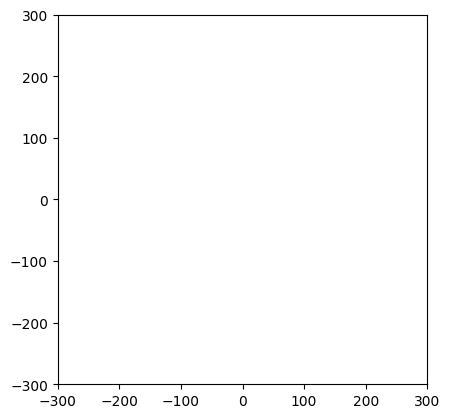

In [90]:
#lets draw a visualization!!!

fig, axies = plt.subplots()

def init():
    return []

def update(frame):
    patches = []
    for body in bodies:
        patches.append(axies.add_patch(plt.Circle(body.history_pos[frame][0:2], radius = body.mass/500, color = 'b')))
    return patches


axies.set_xlim(-300, 300)
axies.set_ylim(-300, 300)
axies.set_aspect('equal', adjustable='box')

animate = animation.FuncAnimation(fig=fig, func=update, init_func=init, frames=30, interval=30, blit=True)

plt.show()

In [76]:
def lagrange(bodies):
    T=.5*(bodies[0].mass*(np.linalg.norm(bodies[0].velo)**2) +bodies[1].mass*(np.linalg.norm(bodies[1].velo)**2) +bodies[2].mass*(np.linalg.norm(bodies[2].velo)**2))
    distance_from_center_1=bodies[0].pos-center_of_mass
    distnace_from_center_2=bodies[1].pos-center_of_mass
    distnace_from_center_3=bodies[2].pos-center_of_mass
    
    V=np.linalg.norm((distance_from_center_1*np.linalg.norm(bodies[0].force)) + (distance_from_center_1*np.linalg.norm(bodies[1].force)) + (distance_from_center_1*np.linalg.norm(bodies[2].force)))
    print(T)
    print(V)
    return (0)
lagrange(bodies)

150692.51983473176
3001.386224901753


0